# Crash Exploratory Analysis using SQL and Python

## Imports & Setting up the working enviroment

In [1]:
import duckdb
import pandas as pd
pd.set_option('display.max_rows', 100)

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Set Seaborn theme and context for better aesthetics
sns.set_theme(style="white")
sns.set_context("notebook", font_scale=1.1)
sns.despine()
%config InlineBackend.figure_format = 'retina'

<Figure size 640x480 with 0 Axes>

In [3]:
con = duckdb.connect('crashes.duckdb')

After establised the connection we can start writing SQL code!

## Load the data

In [4]:
con.execute("""
    CREATE OR REPLACE TABLE crashes AS
    SELECT *
    FROM read_csv_auto('data/Crash_Analysis_System__CAS__data.csv', header=true, sample_size=-1)
""")

result = con.execute("SELECT COUNT(*) AS total_crashes FROM crashes").fetchdf()
print(result)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   total_crashes
0         913464


In [5]:
con.execute(""" DESCRIBE crashes """).fetchdf()

,column_name,column_type,null,key,default,extra
0,X,DOUBLE,YES,None,None,None
1,Y,DOUBLE,YES,None,None,None
2,OBJECTID,BIGINT,YES,None,None,None
3,advisorySpeed,BIGINT,YES,None,None,None
4,areaUnitID,BIGINT,YES,None,None,None
5,bicycle,BIGINT,YES,None,None,None
6,bridge,BIGINT,YES,None,None,None
7,bus,BIGINT,YES,None,None,None
8,carStationWagon,BIGINT,YES,None,None,None
9,cliffBank,BIGINT,YES,None,None,None


There are 913,464 rows and 72 columns in the table.

## Data profiling

In [6]:
con.execute("""
    SELECT
        *
    FROM crashes
    LIMIT 10""").fetchdf()

,X,Y,OBJECTID,advisorySpeed,areaUnitID,bicycle,bridge,bus,carStationWagon,cliffBank,...,train,tree,truck,unknownVehicleType,urban,vanOrUtility,vehicle,waterRiver,weatherA,weatherB
0,1747565.0,5427642.0,1,<NA>,575300,0,<NA>,0,2,<NA>,...,<NA>,<NA>,0,0,Urban,0,<NA>,<NA>,Fine,Null
1,1544693.0,5170620.0,2,<NA>,587020,0,0,0,1,0,...,0,0,0,0,Open,0,0,0,Fine,Null
2,1615685.0,5423963.0,3,<NA>,584201,0,0,0,0,0,...,0,0,0,0,Urban,0,0,0,Fine,Null
3,1799588.0,5821916.0,4,<NA>,527007,0,<NA>,0,2,<NA>,...,<NA>,<NA>,0,0,Urban,0,<NA>,<NA>,Fine,Null
4,1570549.0,5176071.0,5,<NA>,591101,1,<NA>,0,0,<NA>,...,<NA>,<NA>,0,0,Urban,0,<NA>,<NA>,Fine,Null
5,1680069.0,5404460.0,6,<NA>,581230,0,<NA>,0,3,<NA>,...,<NA>,<NA>,0,0,Urban,0,<NA>,<NA>,Fine,Null
6,1394487.0,4916691.0,7,<NA>,606100,0,0,0,2,0,...,0,0,0,0,Urban,0,0,0,Fine,Null
7,1789692.0,5858082.0,8,<NA>,526900,0,0,0,1,0,...,0,0,0,0,Urban,1,0,0,Fine,Null
8,1623513.0,5430552.0,9,<NA>,582700,0,<NA>,0,3,<NA>,...,<NA>,<NA>,0,0,Urban,0,<NA>,<NA>,Light rain,Null
9,1405988.0,4916533.0,10,<NA>,603000,0,<NA>,0,2,<NA>,...,<NA>,<NA>,0,0,Urban,0,<NA>,<NA>,Light rain,Null


The dataset is denormalised into a single flat table which is suitable for the purpose of this exploratory analysis.

What year this dataset covered?

In [7]:
con.execute("""
    SELECT
        MIN(crashYear) AS earliest_year
        , MAX(crashYear) AS latest_year
        , COUNT(distinct crashYear) AS total_years
    FROM crashes
    """).fetchdf()

,earliest_year,latest_year,total_years
0,2000,2026,27


The dataset runs from 2000 to 2026 (27 years).

We nocticed there are many columns contains "<N/A>" values - Pandas missing values display as well as the text "Null" which is the dataset default Null. Let's see how many NULLS are there in each columns.

In [8]:
column_names = con.execute("""DESCRIBE crashes""").fetchdf()['column_name'].tolist()

select_parts = ", ".join([
    f'COUNT(*) FILTER (WHERE "{col}" IS NULL OR CAST("{col}" AS VARCHAR) = \'Null\') AS "{col}"'
    for col in column_names
])

In [9]:
result = con.execute(f"SELECT {select_parts} FROM crashes").fetchdf()

In [10]:
null_df = result.T.reset_index()
null_df.columns = ['column_name', 'null_count']
null_df =null_df.sort_values(by='null_count', ascending=False)

null_df['pct_null'] = null_df['null_count'] / 913464 * 100

In [11]:
null_df.head(5)

,column_name,null_count,pct_null
27,intersection,913464,100.000000
14,crashRoadSideRoad,913464,100.000000
56,temporarySpeedLimit,897788,98.283895
40,pedestrian,883236,96.690838
71,weatherB,881993,96.554763


In [12]:
null_df.tail(5)

,column_name,null_count,pct_null
17,crashYear,0,0.0
15,crashSeverity,0,0.0
44,roadCharacter,0,0.0
59,trafficControl,0,0.0
66,urban,0,0.0


There are columns where we have complete data such as crashYear, crashSeverity, roadCharacter etc but there are also columns where we have absolutely all null values such as intersection, crashRoadSideRoad etc. Additionally there are 29 columns with more than 50% nulls.

Any duplicated records?

In [13]:
con.execute("""SELECT COUNT(DISTINCT OBJECTID) FROM crashes""").fetchdf()

,count(DISTINCT OBJECTID)
0,913464


There are no duplicated keys, all records are distinct.

#### Data Profile Summary

The Crash Analysis System (CAS) dataset contains **913,464 crash records** spanning **27 years** (2000-2026), organized in a single denormalized table with **72 columns**. Each record represents a unique crash incident identified by the OBJECTID field.

**Completeness:**
- **High-quality columns**: Several key fields have complete data including crashYear, crashSeverity, and roadCharacter
- **Severely incomplete columns**: Multiple columns contain 100% null values (intersection, crashRoadSideRoad, etc.)
- **Moderate missingness**: 29 columns have more than 50% missing data

**Data Integrity:**
- ✅ **No duplicates**: All 913,464 records have unique OBJECTID values
- ⚠️ **Mixed null representations**: Dataset uses both actual NULL values and text "Null" as missing data indicators

## Data Cleaning

We will create a VIEW and work on that VIEW so that the original data stays untouched.

In [14]:
query = open('sql/02_clean.sql').read()
con.execute(query)

crashes_cleaned = con.execute("SELECT * FROM crashes_clean").fetchdf()
crashes_cleaned.head(10)

,year,region,tla,severity,weather,light,speed_limit,fatal_count,serious_count,minor_count,holiday_flag
0,2015,Auckland Region,Auckland,Minor Crash,Fine,Bright sun,50,0,0,1,Normal day
1,2015,Canterbury Region,Christchurch City,Minor Crash,Fine,Twilight,50,0,0,1,Normal day
2,2015,Canterbury Region,Christchurch City,Serious Crash,Fine,Overcast,50,0,1,0,Normal day
3,2015,Southland Region,Invercargill City,Minor Crash,Fine,Dark,50,0,0,2,Normal day
4,2015,Bay of Plenty Region,Tauranga City,Minor Crash,Fine,Bright sun,50,0,0,1,Normal day
5,2015,Wellington Region,Lower Hutt City,Minor Crash,Light rain,Dark,100,0,0,1,Normal day
6,2015,Canterbury Region,Selwyn District,Non-Injury Crash,Fine,Bright sun,100,0,0,0,Normal day
7,2015,Auckland Region,Auckland,Minor Crash,Light rain,Dark,50,0,0,1,Normal day
8,2015,Auckland Region,Auckland,Minor Crash,Fine,Dark,50,0,0,1,Normal day
9,2015,Northland Region,Far North District,Minor Crash,Fine,Bright sun,100,0,0,1,Christmas New Year


In [15]:
con.execute("""SELECT COUNT(*) AS total_crashes FROM crashes_clean;""").fetchdf()

,total_crashes
0,343129


In [16]:
con.execute("""SELECT MIN(year) AS first_year,
       MAX(year) AS last_year,
       COUNT(DISTINCT year) AS year_count
FROM crashes_clean;""").fetchdf()

,first_year,last_year,year_count
0,2015,2024,10


### Data Cleaning Steps Applied
**1. Column Standardization**: Renamed columns to more consistent naming.

**2. Text Field**: For categorical columns (region, tla, severity, weather, light, holiday_flag):
- Trimmed whitespace
- Converted empty strings and 'Null' text values to actual NULL
- Replaced NULL values with 'Unknown' (or 'Normal day' for holidays)

**3. Numeric Field**: Set NULL counts to 0 for crash statistics (fatal_count, serious_count, minor_count).

**4. Data Filtering**: Restricted dataset to years 2015-2024 only.

## Answering Business Quesitons
### 1. Is NZ road safety actually improving over time?

In [17]:
query = open('sql/q1_trend.sql').read()
trend_result = con.execute(query).fetchdf()

In [18]:
trend_result

,year,total_crashes,deaths,serious_injuries,total_crashes_change,total_crashes_pct_change,serious_injuries_change,serious_injuries_pct_change,deaths_change,deaths_pct_change
0,2015,32104,317.0,2165.0,<NA>,NaN,NaN,NaN,NaN,NaN
1,2016,37250,327.0,2549.0,5146,16.029156,384.0,17.736721,10.0,3.154574
2,2017,39314,377.0,2861.0,2064,5.540940,312.0,12.240094,50.0,15.290520
3,2018,38470,378.0,2600.0,-844,-2.146818,-261.0,-9.122684,1.0,0.265252
4,2019,36930,350.0,2527.0,-1540,-4.003119,-73.0,-2.807692,-28.0,-7.407407
5,2020,32819,318.0,2186.0,-4111,-11.131871,-341.0,-13.494262,-32.0,-9.142858
6,2021,34154,320.0,2328.0,1335,4.067766,142.0,6.495883,2.0,0.628931
7,2022,31251,371.0,2498.0,-2903,-8.499737,170.0,7.302405,51.0,15.937500
8,2023,31505,341.0,2460.0,254,0.812774,-38.0,-1.521217,-30.0,-8.086253
9,2024,29332,292.0,2466.0,-2173,-6.897318,6.0,0.243902,-49.0,-14.369501


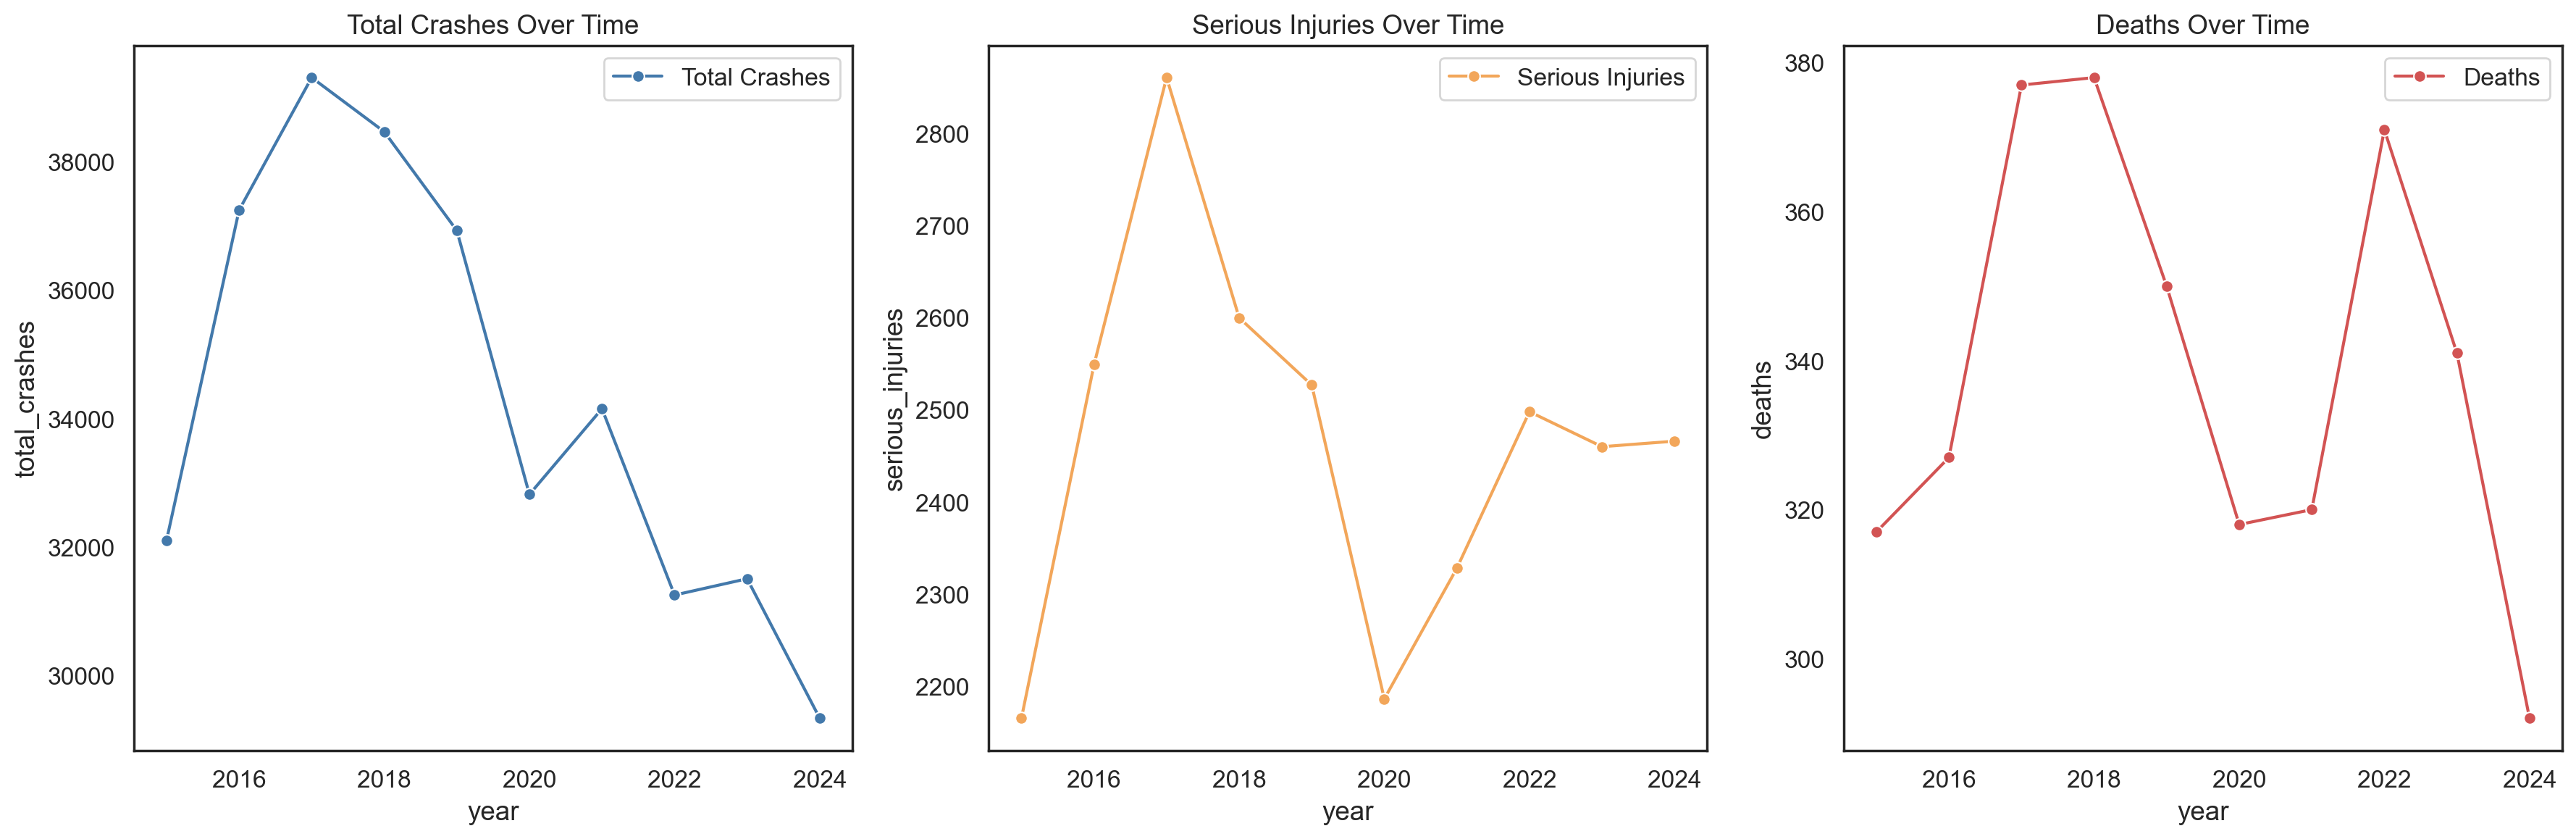

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.lineplot(data=trend_result, x='year', y='total_crashes', marker='o', label='Total Crashes', color='#4379AB', ax=axes[0])
sns.lineplot(data=trend_result, x='year', y='serious_injuries', marker='o', label='Serious Injuries', color='#F2A65A', ax=axes[1])
sns.lineplot(data=trend_result, x='year', y='deaths', marker='o', label='Deaths', color='#D25353', ax=axes[2])
axes[0].set_title('Total Crashes Over Time')
axes[1].set_title('Serious Injuries Over Time')
axes[2].set_title('Deaths Over Time')
plt.tight_layout()
plt.show()

**Key Findings:**
- The overall number of crashes increased between 2015 and 2017, followed by a marked decline through to 2024.
- After the introduction of the Road to Zero initiative in late 2019, total crashes decreased from 36,930 in 2019 to 29,332 in 2024, representing an approximate **20% reduction**.
- However, improvements in more severe outcomes have been more modest, with serious crashes and fatalities declining by only 2.4% and 7.8%, respectively, over the same period.
- Despite an overall downward trend, fluctuations remain evident. Most notably, fatalities surged in 2022, increasing by 15% compared to 2021. In addition, serious injuries showed signs of reversal, rising from 2,186 in 2020 to 2,498 in 2022.

### 2. When are the times that crashes most likely to occur?

In [20]:
con.execute("""SELECT * FROM crashes_clean LIMIT 5""").fetchdf()

,year,region,tla,severity,weather,light,speed_limit,fatal_count,serious_count,minor_count,holiday_flag
0,2015,Auckland Region,Auckland,Minor Crash,Fine,Bright sun,50,0,0,1,Normal day
1,2015,Canterbury Region,Christchurch City,Minor Crash,Fine,Twilight,50,0,0,1,Normal day
2,2015,Canterbury Region,Christchurch City,Serious Crash,Fine,Overcast,50,0,1,0,Normal day
3,2015,Southland Region,Invercargill City,Minor Crash,Fine,Dark,50,0,0,2,Normal day
4,2015,Bay of Plenty Region,Tauranga City,Minor Crash,Fine,Bright sun,50,0,0,1,Normal day


In [21]:
query = open('sql/q2_when.sql').read()
period_crashes = con.execute(query).fetchdf()
period_crashes

,period_type,crashes,serious_crashes,deaths,serious_rate_pct,fatality_rate_pct,light_rate_pct
0,Holiday period,19345,1745.0,268.0,9.02,1.39,89.59
1,Normal day,323784,22895.0,3123.0,7.07,0.96,91.97


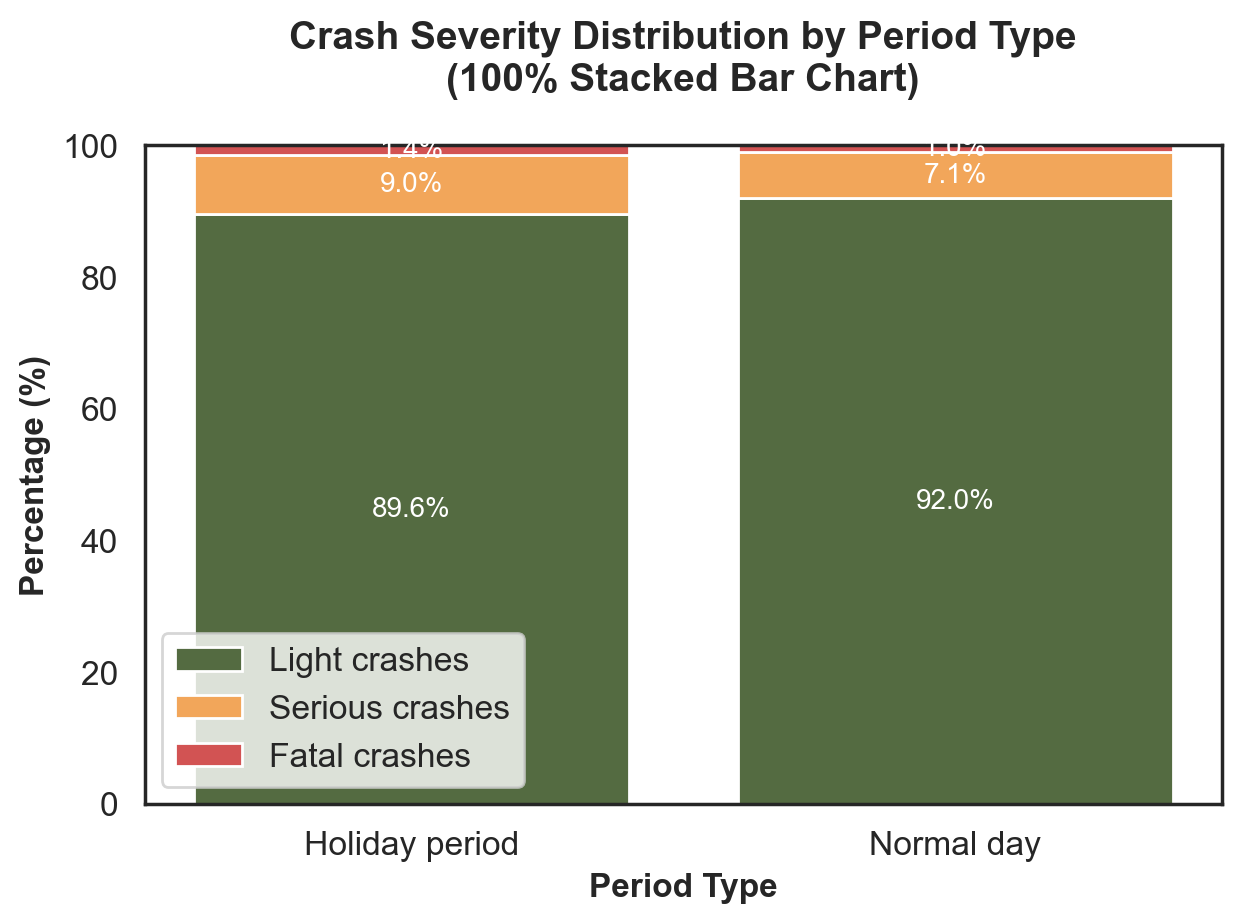

In [22]:
#plt.figure(figsize=(10, 8))
# Extract the data for plotting
period_types = period_crashes['period_type']
serious_rate = period_crashes['serious_rate_pct']
fatality_rate = period_crashes['fatality_rate_pct'] 
light_rate = period_crashes['light_rate_pct']

# Create the stacked bars
x_pos = np.arange(len(period_types))

# Plot each segment
bar1 = plt.bar(x_pos, light_rate, label='Light crashes', color='#546B41')
bar2 = plt.bar(x_pos, serious_rate, bottom=light_rate, label='Serious crashes', color='#F2A65A')
bar3 = plt.bar(x_pos, fatality_rate, bottom=light_rate + serious_rate, label='Fatal crashes', color='#D25353')

# Customize the plot
plt.xlabel('Period Type', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Crash Severity Distribution by Period Type\n(100% Stacked Bar Chart)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(x_pos, period_types)
plt.ylim(0, 100)

# Add percentage labels on each segment
for i in range(len(period_types)):
    # Light crashes label (center of segment)
    plt.text(i, light_rate.iloc[i]/2, f'{light_rate.iloc[i]:.1f}%', 
             ha='center', va='center', color='white', fontsize=10)
    
    # Serious crashes label (center of segment) 
    plt.text(i, light_rate.iloc[i] + serious_rate.iloc[i]/2, f'{serious_rate.iloc[i]:.1f}%',
             ha='center', va='center', color='white', fontsize=10)
    
    # Fatal crashes label (center of segment)
    plt.text(i, light_rate.iloc[i] + serious_rate.iloc[i] + fatality_rate.iloc[i]/2, f'{fatality_rate.iloc[i]:.1f}%',
             ha='center', va='center', color='white', fontsize=10)

# Add legend
plt.legend()

plt.tight_layout()
plt.show()

**Key Findings:**
- There is a clear distinction in the rate of severe crashes between holiday periods and normal days. 
- The fatality rate during holiday periods is 1.39%, compared to 0.96% on non-holiday days.
- This pattern is even more pronounced for serious crashes, where the serious crash rate percentage in holiday period is **1.94 higher** than non-holiday period.

### 3. Crashes Per Capita Rankings by Region

Note: Per-capita rates use Stats NZ 2023 regional population estimates applied across 2020–2024. Regional populations shifted modestly over this period so figures are indicative rather than exact.

In [23]:
## Read the StatsNZ population data into the database
con.execute("""CREATE OR REPLACE TABLE population AS
SELECT
    Region as region,
    CAST(REPLACE(population_2018, ',', '') AS INTEGER) AS population_2018,
    CAST(REPLACE(population_2023, ',', '') AS INTEGER) AS population_2023,
    CAST(REPLACE(population_2024, ',', '') AS INTEGER) AS population_2024,
    CAST(REPLACE(population_2025, ',', '') AS INTEGER) AS population_2025
FROM read_csv_auto('data/statsnz_regional_population.csv', header=true);""")

In [24]:
con.execute("""SELECT * FROM population""").fetchdf()

,region,population_2018,population_2023,population_2024,population_2025
0,Northland region,185800,198500,200400,201100
1,Auckland region,1654800,1755200,1798300,1816000
2,Waikato region,475600,516800,527000,532100
3,Bay of Plenty region,320800,346500,350500,351500
4,Gisborne region,49500,52300,52800,52700
5,Hawke's Bay region,172400,179000,179800,179700
6,Taranaki region,121200,129400,130300,130300
7,Manawatū-Whanganui region,247500,257800,260100,260700
8,Wellington region,525900,538000,543300,543400
9,Tasman region,54000,59100,59700,59900


Noticed there is inconsistency in the region columns between 2 tables we need to fix that before joining.

In [25]:
query = open('sql/q3_per_capita.sql').read()
per_capita_result = con.execute(query).fetchdf()
per_capita_result

,region,total_deaths,population_2023,deaths_per_100k,rank_per_capita
0,Northland region,163.0,198500,82.12,1
1,Marlborough region,38.0,50800,74.80,2
2,West Coast region,23.0,33900,67.85,3
3,Manawatū-Whanganui region,169.0,257800,65.55,4
4,Gisborne region,31.0,52300,59.27,5
5,Waikato region,304.0,516800,58.82,6
6,Southland region,43.0,102700,41.87,7
7,Bay of Plenty region,145.0,346500,41.85,8
8,Hawke's Bay region,70.0,179000,39.11,9
9,Taranaki region,49.0,129400,37.87,10


**Key Findings:**
The regions with the highest risk, measured by normalized fatal crash rates per capita, are Northland, Marlborough, the West Coast, Manawatū–Whanganui, and Gisborne. Each of these regions records **more than 59 fatal crashes per 100,000 population.**

**What this means:**
Even after accounting for population size, people in these regions are significantly more likely to be involved in fatal crashes compared to other parts of the country. In simple terms, the risk of dying in a crash is higher in these areas, not just because of how many people live there, but due to underlying factors such as road conditions, travel patterns, or driver behavior.

### 4. What environmental factors are over-represented in fatal crashes vs minor ones?

In [26]:
con.execute("""SELECT * FROM crashes_clean LIMIT 5""").fetchdf()

,year,region,tla,severity,weather,light,speed_limit,fatal_count,serious_count,minor_count,holiday_flag
0,2015,Auckland Region,Auckland,Minor Crash,Fine,Bright sun,50,0,0,1,Normal day
1,2015,Canterbury Region,Christchurch City,Minor Crash,Fine,Twilight,50,0,0,1,Normal day
2,2015,Canterbury Region,Christchurch City,Serious Crash,Fine,Overcast,50,0,1,0,Normal day
3,2015,Southland Region,Invercargill City,Minor Crash,Fine,Dark,50,0,0,2,Normal day
4,2015,Bay of Plenty Region,Tauranga City,Minor Crash,Fine,Bright sun,50,0,0,1,Normal day


In [27]:
query = open('sql/q4_factors.sql').read()
factors_result = con.execute(query).fetchdf()
factors_result

,weather,total_crashes,fatal_crashes,base_line_fatality_rate,fatal_rate,relative_risk
0,Mist or Fog,5125,67.0,0.008775,0.013073,1.49
1,Fine,262538,2470.0,0.008775,0.009408,1.07
2,Heavy rain,12015,106.0,0.008775,0.008822,1.01
3,Light rain,50629,360.0,0.008775,0.007111,0.81


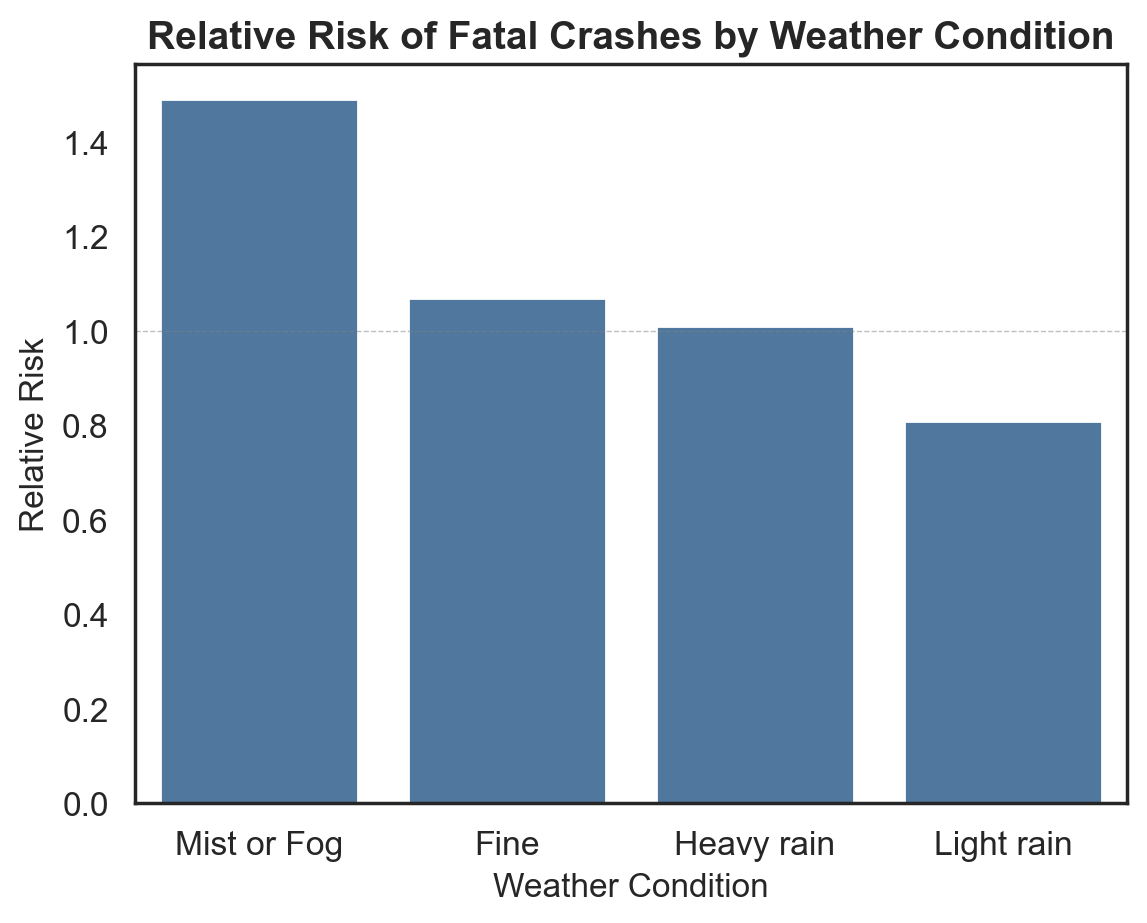

In [28]:
sns.barplot(data=factors_result, x='weather', y='relative_risk', color='#4379AB')

# Add reference line at y=1.0 (no effect/baseline risk)
plt.axhline(y=1.0, color='grey', linestyle='--', alpha=0.5, linewidth=.5)

plt.title('Relative Risk of Fatal Crashes by Weather Condition', fontsize=14, fontweight='bold')
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Relative Risk', fontsize=12)
plt.show()

**Note:**

A relative risk of:

- 1.0 = exactly as dangerous as average
- 2.0 = twice as dangerous as average
- 0.5 = half as dangerous as average (safer than average)

**Key Findings:**
- After filtering to weather conditions with over 1,000 recorded crashes — ensuring statistically reliable results — **mist and fog** emerged as the most dangerous conditions, with crashes **1.5x more likely** to be fatal than the national average.
- Notably, **light rain** showed a relative risk of 0.81, meaning crashes under this condition are actually **19% less likely** to be fatal than average — a counterintuitive finding that likely reflects drivers naturally slowing down in light rain.

### 5. Did Road To Zero Change Outcomes?

The different in number of raw deaths or serious injuries counts could be explained by the difference in total crashes. We are interested in the severity of individual crashes so we will use counts per 10k crashes to measure that.

In [36]:
query = open('sql/q5_policy.sql').read()
con.execute(query).fetchdf()

,era,total_crashes,deaths,deaths_per_10k_crashes,serious_injuries,serious_injuries_per_10k_crashes
0,Post-RtZ,126242,1324.0,104.88,9752.0,772.48
1,Pre-RtZ,147138,1399.0,95.08,10175.0,691.53


**Key Findings:**
- Total road deaths remained essentially unchanged between the pre- and post-policy periods, at approximately 1,300 fatalities in each cohort. However, crash severity tells a more concerning story: the fatality rate increased from 95.08 to 104.88 deaths per 10,000 crashes after Road to Zero launched — meaning individual crashes became more likely to be fatal, not less.
- Serious injuries showed a more encouraging trend, falling from 10,175 to 9,752 in raw terms. Yet the same severity problem appears here too — serious injuries per 10,000 crashes rose from 691.53 to 772.48, suggesting the improvement in raw counts is largely explained by fewer total crashes rather than crashes becoming less harmful.
- Taken together, these findings suggest Road to Zero has not yet delivered measurable improvements in crash severity. The reduction in serious injuries is a positive signal, but it appears driven by reduced crash frequency rather than safer outcomes when crashes do occur. It is worth noting that this analysis covers only the first four years post-launch — longer-term data may reveal a clearer trend.

### 6. Bonus: Road to Zero Impacts on High Way vs. City Road

In [48]:
query = open('sql/extra_roadtype.sql').read()
con.execute(query).fetchdf()

,era,road_type,total_crashes,deaths,deaths_per_10k_crashes,serious_injuries,serious_injuries_per_10k_crashes
0,Post-RtZ,City Street,92118,540.0,58.62,5916.0,642.22
1,Pre-RtZ,City Street,104813,463.0,44.17,5552.0,529.71
2,Post-RtZ,High Way,34124,784.0,229.75,3836.0,1124.14
3,Pre-RtZ,High Way,42325,936.0,221.15,4623.0,1092.26


**Key Findings:**
- Breaking the analysis down by road type reveals that the worsening severity trend holds across both city streets and highways — suggesting road type had no moderating effect on policy outcomes.
- On city streets, the fatality rate rose sharply from 44.17 to 58.62 deaths per 10,000 crashes, a 33% increase. Serious injuries followed the same direction, climbing from 529.71 to 642.22 per 10,000 crashes. 
- On highways, the picture is similar though less dramatic — fatality rate increased from 221.15 to 229.75, and serious injuries per 10,000 crashes rose from 1,092.26 to 1,124.14.
- Notably, highways are consistently more dangerous than city streets on a per-crash basis — roughly 4x the fatality rate — which reflects the higher speeds involved.
- But the post-policy deterioration in severity is present on both road types, reinforcing the conclusion from Q5 that Road to Zero has not yet translated into safer individual crashes.